In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

# Agregamos la carpeta superior (la raíz del proyecto) al sistema de búsqueda
sys.path.append(os.path.abspath(".."))

from src.utils.cleaning_methods import *


## Carga de datos

In [2]:
# Declaración del Path y carga del csv en un dataframe
PATH = '../output/catalog_film.csv'
df_original = charge_path(PATH)
df = df_original.copy()
df.head()

,inventory_id,title,category,length,rating,language,total_inventory,total_rentals
0,1,academy dinosaur,documentary,86,PG,english,1,3
1,2,academy dinosaur,documentary,86,PG,english,1,5
2,3,academy dinosaur,documentary,86,PG,english,1,2
3,4,academy dinosaur,documentary,86,PG,english,1,2
4,6,academy dinosaur,documentary,86,PG,english,1,5


## Exploración rápida del dataset

In [3]:
num_columnas, num_filas, num_duplicados, null_values, df_porcentaje_nulos_columna, df_describe_numeric, df_describe_categorical = first_visualizer(df)

In [4]:
show_head(df)

,inventory_id,title,category,length,rating,language,total_inventory,total_rentals
0,1,academy dinosaur,documentary,86,PG,english,1,3
1,2,academy dinosaur,documentary,86,PG,english,1,5
2,3,academy dinosaur,documentary,86,PG,english,1,2
3,4,academy dinosaur,documentary,86,PG,english,1,2
4,6,academy dinosaur,documentary,86,PG,english,1,5
5,7,academy dinosaur,documentary,86,PG,english,1,4
6,8,academy dinosaur,documentary,86,PG,english,1,2
7,9,ace goldfinger,horror,48,G,english,1,2
8,10,ace goldfinger,horror,48,G,english,1,3
9,11,ace goldfinger,horror,48,G,english,1,2


In [5]:
print(f'El dataset tiene {num_filas} filas.')
print(f'El dataset tiene {num_columnas} columnas.')

El dataset tiene 4580 filas.
El dataset tiene 8 columnas.


In [6]:
print(f'El dataset tiene {num_duplicados} duplicados.')

El dataset tiene 0 duplicados.


In [7]:
print(f'El dataset tiene {null_values} valores nulos.\n')
print('Valores nulos por columna:')
df_porcentaje_nulos_columna

El dataset tiene 0 valores nulos.

Valores nulos por columna:


(inventory_id       0.0
 title              0.0
 category           0.0
 length             0.0
 rating             0.0
 language           0.0
 total_inventory    0.0
 total_rentals      0.0
 dtype: float64,
 2)

In [8]:
show_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4580 entries, 0 to 4579
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   inventory_id     4580 non-null   int64 
 1   title            4580 non-null   object
 2   category         4580 non-null   object
 3   length           4580 non-null   int64 
 4   rating           4580 non-null   object
 5   language         4580 non-null   object
 6   total_inventory  4580 non-null   int64 
 7   total_rentals    4580 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 286.4+ KB


In [9]:
df_describe_numeric

,inventory_id,length,total_inventory,total_rentals
count,4580.000000,4580.000000,4580.0,4580.000000
mean,2291.499127,114.935590,1.0,3.503057
std,1322.277958,40.063566,0.0,1.115610
min,1.000000,46.000000,1.0,1.000000
25%,1146.750000,81.000000,1.0,3.000000
50%,2291.500000,114.000000,1.0,4.000000
75%,3436.250000,148.000000,1.0,4.000000
max,4581.000000,185.000000,1.0,5.000000


In [10]:
df_describe_categorical

,title,category,rating,language
count,4580,4580,4580,4580
unique,958,16,5,1
top,zorro ark,sports,PG-13,english
freq,8,344,1018,4580


Al realizar esta exploración podemos ver que el dataset no presenta duplicados, valores nulos y los diferentes tipos de columnas y sus tipos. Al hacer un analisis podemos observar como la columna `languaje` es la misma en todos los registros, por lo que no aporta información y tendríamos que proceder a elimnarla en futuros pasos.

## Normalización

Unificamos todos los datos para que estén en el mismo formato, es decir todos en minúsuclas y en el caso de poseer un espacio, sustituirlo por `_`.

In [11]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

In [12]:
# Normalización a tipo fecha y string
df_cleandf_clean = normalize_date_columns(df)
df_clean = normalize_string_columns(df)

In [13]:
show_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4580 entries, 0 to 4579
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   inventory_id     4580 non-null   int64 
 1   title            4580 non-null   string
 2   category         4580 non-null   string
 3   length           4580 non-null   int64 
 4   rating           4580 non-null   string
 5   language         4580 non-null   string
 6   total_inventory  4580 non-null   int64 
 7   total_rentals    4580 non-null   int64 
dtypes: int64(4), string(4)
memory usage: 286.4 KB


## Borrado de comunas que no aportan valor

In [14]:
df = delete_columns(df, ['language'])

In [15]:
show_head(df, 5)

,inventory_id,title,category,length,rating,total_inventory,total_rentals
0,1,academy dinosaur,documentary,86,pg,1,3
1,2,academy dinosaur,documentary,86,pg,1,5
2,3,academy dinosaur,documentary,86,pg,1,2
3,4,academy dinosaur,documentary,86,pg,1,2
4,6,academy dinosaur,documentary,86,pg,1,5


In [16]:
show_info(df_clean)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4580 entries, 0 to 4579
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   inventory_id     4580 non-null   int64 
 1   title            4580 non-null   string
 2   category         4580 non-null   string
 3   length           4580 non-null   int64 
 4   rating           4580 non-null   string
 5   language         4580 non-null   string
 6   total_inventory  4580 non-null   int64 
 7   total_rentals    4580 non-null   int64 
dtypes: int64(4), string(4)
memory usage: 286.4 KB


## Tratamiento de valores Nulos y Outliers

In [17]:
identify_nulls(df)

--------------------------------
En este caso no se encuentran valores nulos por lo que no se procede a eliminar filas.


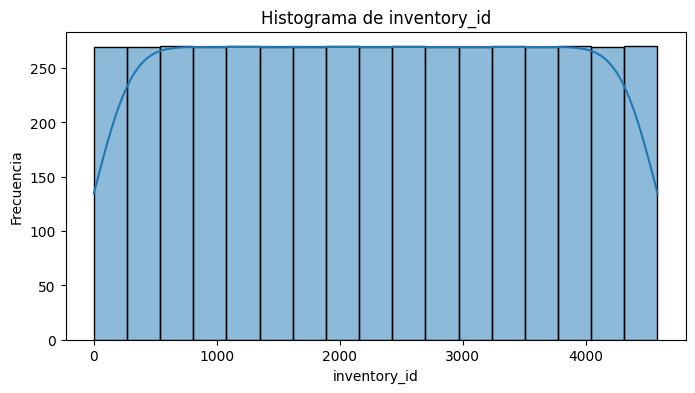

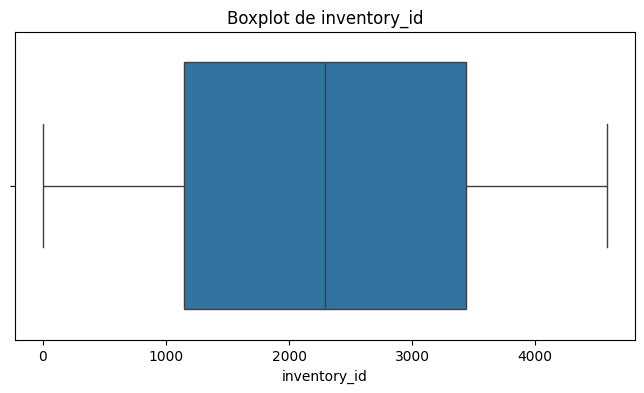

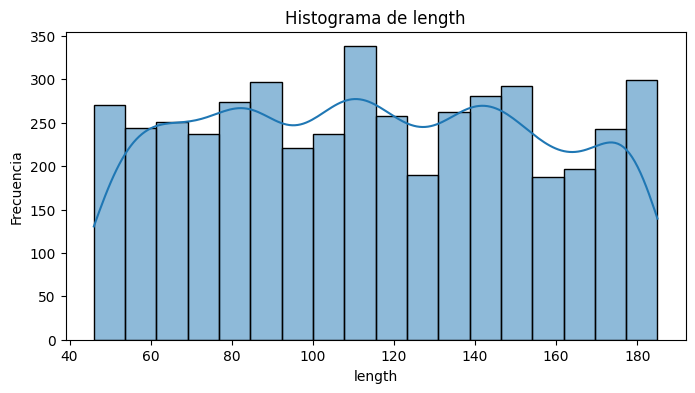

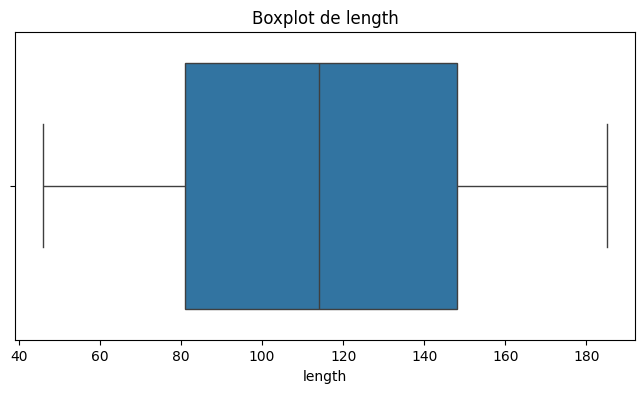

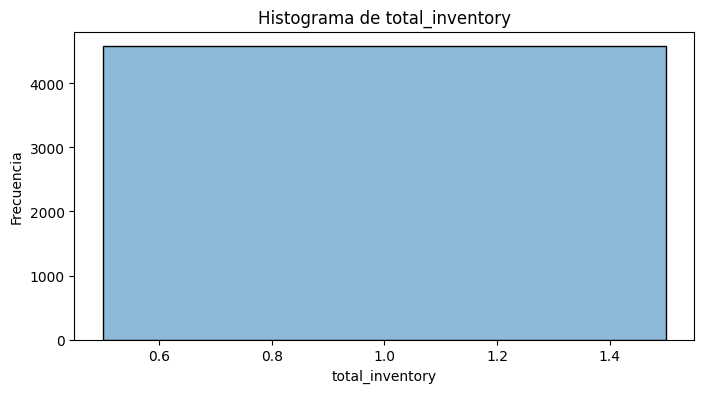

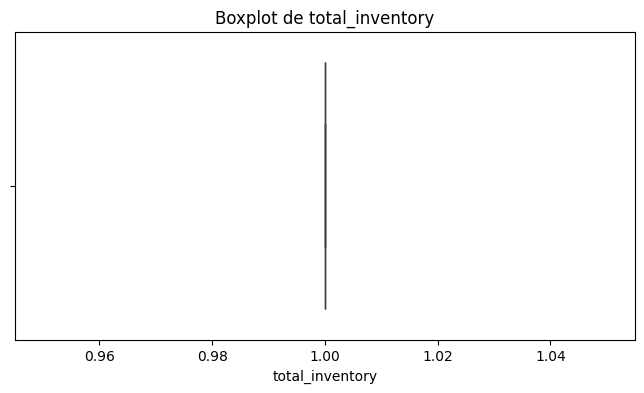

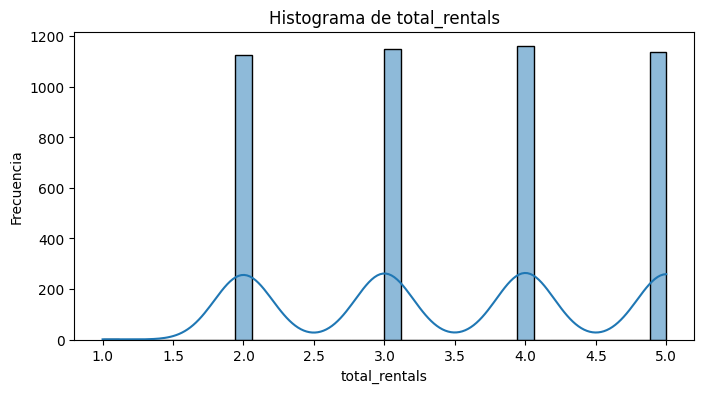

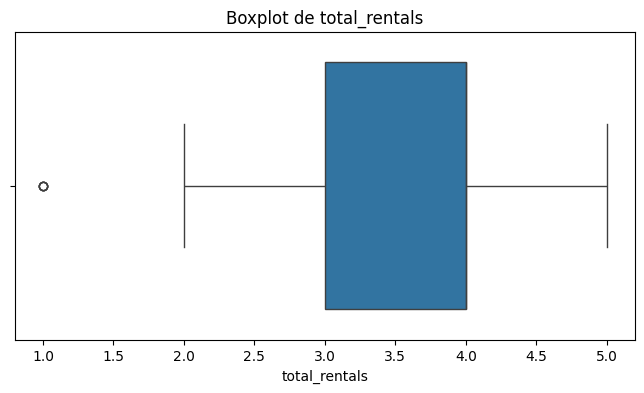

In [18]:
columns_numeric = df.select_dtypes("number").columns
columns_categorical = df.select_dtypes("object").columns

identify_outliers(df,columns_numeric,columns_categorical)

In [19]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4580 entries, 0 to 4579
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   inventory_id     4580 non-null   int64 
 1   title            4580 non-null   string
 2   category         4580 non-null   string
 3   length           4580 non-null   int64 
 4   rating           4580 non-null   string
 5   total_inventory  4580 non-null   int64 
 6   total_rentals    4580 non-null   int64 
dtypes: int64(4), string(3)
memory usage: 250.6 KB


En este caso podemos observar tanto en el código como en la gráfica la ausencia de valores outliers

C:\Users\danie\AppData\Local\Temp\ipykernel_9280\18115750.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


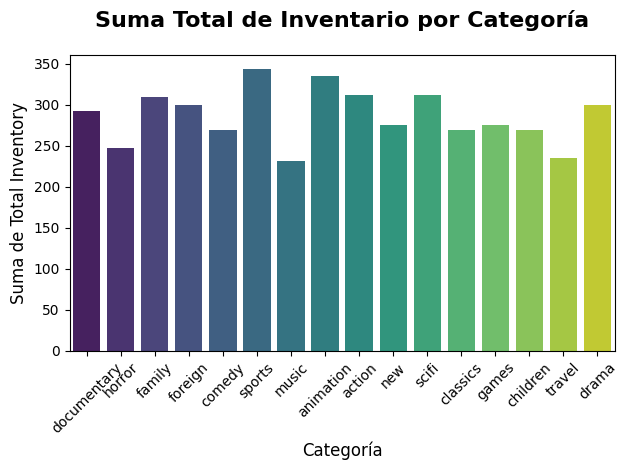

In [20]:
sns.barplot(
    data=df, 
    x='category', 
    y='total_inventory', 
    estimator=sum, 
    errorbar=None,
    palette='viridis'
)

plt.title('Suma Total de Inventario por Categoría', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Suma de Total Inventory', fontsize=12)

plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

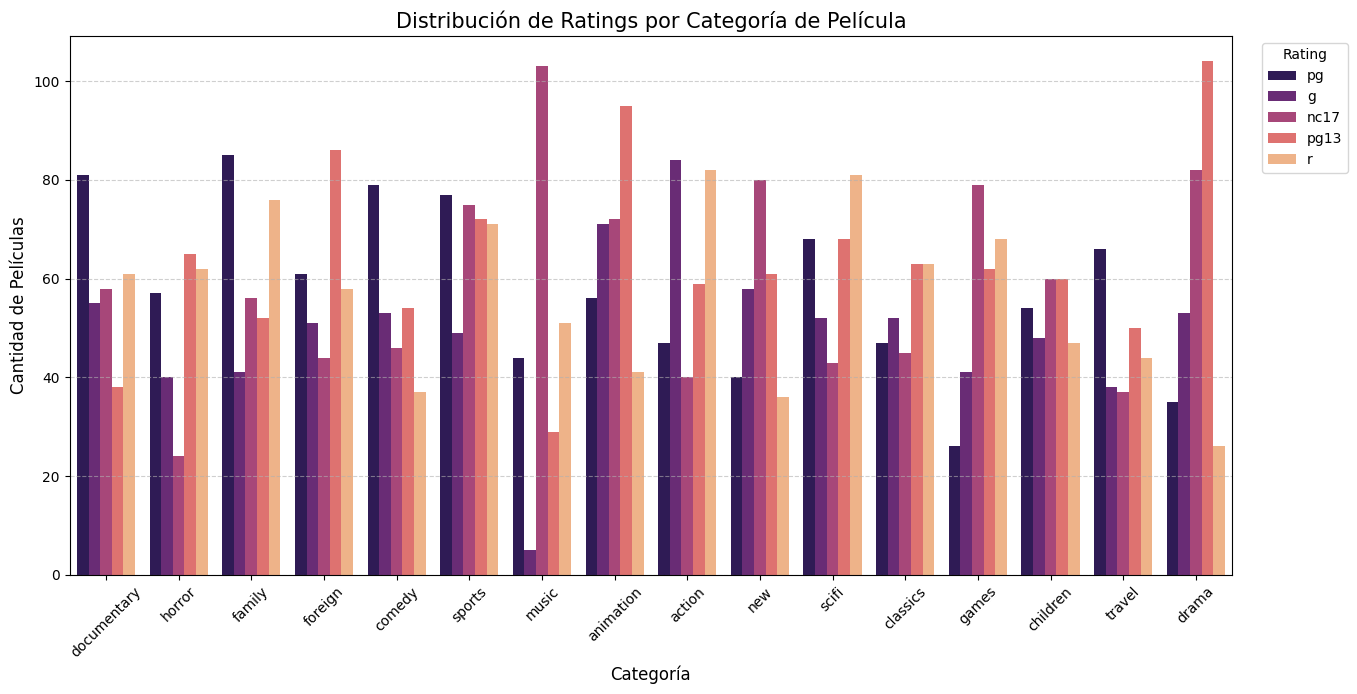

In [21]:
# Configuramos el tamaño de la figura 
plt.figure(figsize=(15, 7))

# Creamos el gráfico de barras
# x: Categoría, hue: Rating (colores por cada tipo de clasificación)
sns.countplot(data=df, x='category', hue='rating', palette='magma')

# Personalización de etiquetas
plt.title('Distribución de Ratings por Categoría de Película', fontsize=15)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Cantidad de Películas', fontsize=12)

# Rotamos los nombres de las categorías 45 grados para que sean legibles
plt.xticks(rotation=45)

# Movemos la leyenda fuera del gráfico para que no tape las barras
plt.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.6) # Una rejilla ligera para ayudar a leer los valores
plt.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_9280\1657567041.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='length', palette='Set3')


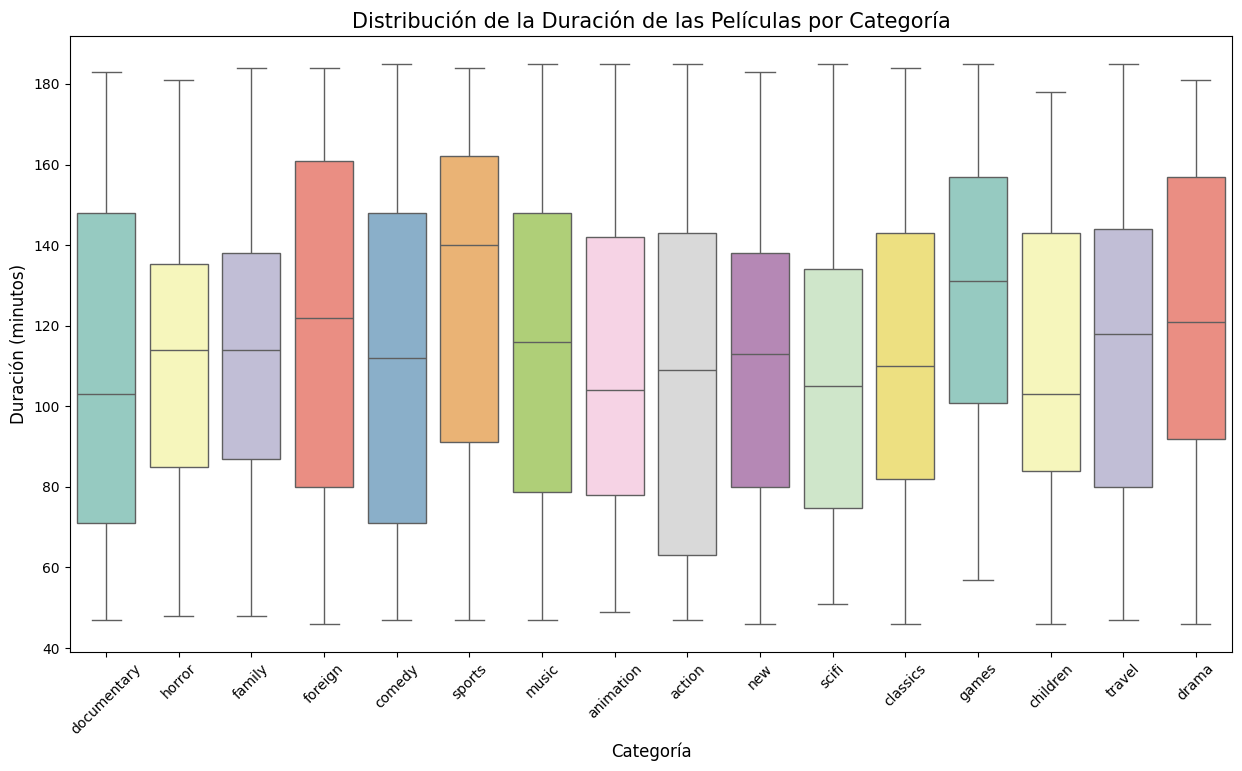

In [22]:
plt.figure(figsize=(15, 8))

# x: Categoría, y: Duración
sns.boxplot(data=df, x='category', y='length', palette='Set3')

plt.title('Distribución de la Duración de las Películas por Categoría', fontsize=15)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Duración (minutos)', fontsize=12)
plt.xticks(rotation=45)

plt.show()